# NOTEBOOK 1 : CHAIN LADDER AGREGE
## Modelisation de la structure par terme des remboursements anticipes

## Introduction

### Pourquoi une approche agregee ?

La methode Chain Ladder classique s'applique a des donnees longitudinales (suivi du meme contrat dans le temps). Notre base etant une **coupe transversale** (un contrat observe une seule fois), nous devons travailler au **niveau cohorte agrege**.

### Principe (selon le professeur)

Pour chaque cohorte (groupe de contrats avec la meme periode d'origination) :

1. Calculer le **CRD total** = somme des (MTECH × B_MAT) de la cohorte
2. Calculer le **RA cumule** a chaque age = somme des remboursements anticipes
3. Calculer l'**ER cumule** = RA cumule / CRD initial

On obtient un **triangle cumule** ou :
- Lignes = cohortes
- Colonnes = ages du pret
- Valeurs = ER cumule

### Formule CRD selon le professeur

```
CRD = MTECH × B_RESMAT - RA
ER = RA / CRD
```

Pour l'agregation par cohorte, on utilise le capital initial (MTECH × B_MAT) comme reference fixe.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Bibliotheques chargees")

Bibliotheques chargees


## Etape 1 : Chargement et preparation

In [2]:
df=pd.read_csv("Export_ER_Agrege.csv", sep=";")
df.columns

Index(['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET',
       'E_OFF', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx',
       'EAD', 'AGE_PRET', 'HORIZON_RES', 'CSP_grp', 'CRD', 'ER_obs', 'FLAG_ER',
       'Capital_initial', 'Date_origination', 'Cohorte'],
      dtype='object')

In [3]:
import pandas as pd

df["Date_origination"] = pd.to_datetime(df["Date_origination"], errors="coerce")

df_2021 = df[df["Date_origination"] >= "2021-01-01"].copy()

nb_obs = len(df_2021)                 # nb de lignes
nb_prets = df_2021["ID"].nunique()    # nb de prêts uniques

nb_obs, nb_prets

(11613, 11613)

In [4]:
nb_obs = len(df)                 # nb de lignes
nb_prets = df["ID"].nunique()    # nb de prêts uniques

nb_obs, nb_prets

(63585, 63585)

In [5]:
df["Date_origination"].min(), df["Date_origination"].max()

(Timestamp('2006-01-11 00:00:00'), Timestamp('2023-12-01 00:00:00'))

In [6]:
import pandas as pd

df["Date_origination"] = pd.to_datetime(df["Date_origination"], errors="coerce")

prets_par_annee = (
    df.dropna(subset=["Date_origination"])
      .assign(annee=df["Date_origination"].dt.year)
      .groupby("annee")["ID"]
      .nunique()
      .sort_index()
)

print(prets_par_annee)

annee
2006        1
2007        8
2008        8
2009       13
2010       39
2011      220
2012      385
2013      634
2014     1029
2015     2224
2016     4848
2017     8825
2018    13005
2019    11995
2020     8738
2021     6943
2022     3948
2023      722
Name: ID, dtype: int64


In [7]:
print("Colonnes disponibles :")
print(df.columns.tolist())

print("\nStatistiques B_RESMAT :")
print(df['B_RESMAT'].describe())

print("\nStatistiques NB_ECH :")
print(df['NB_ECH'].describe())

# Si B_RESMAT ≈ NB_ECH → c'est en échéances
# Si B_RESMAT << NB_ECH → c'est probablement en mois

print(f"\nRatio moyen B_RESMAT / NB_ECH : {(df['B_RESMAT'] / df['NB_ECH']).mean():.2f}")

Colonnes disponibles :
['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET', 'E_OFF', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx', 'EAD', 'AGE_PRET', 'HORIZON_RES', 'CSP_grp', 'CRD', 'ER_obs', 'FLAG_ER', 'Capital_initial', 'Date_origination', 'Cohorte']

Statistiques B_RESMAT :
count    63585.000000
mean        44.314492
std         30.996450
min          1.000000
25%         22.000000
50%         38.000000
75%         57.000000
max        167.000000
Name: B_RESMAT, dtype: float64

Statistiques NB_ECH :
count    63585.000000
mean        69.535346
std         33.382598
min          2.000000
25%         48.000000
50%         60.000000
75%         79.000000
max        170.000000
Name: NB_ECH, dtype: float64

Ratio moyen B_RESMAT / NB_ECH : 0.61


## Etape 3 : Filtrage sur 10 dernieres annees

Pour avoir un triangle plus dense, on filtre sur les 10 dernieres annees.

In [8]:
# Filtrer 10 dernieres annees (40 trimestres)
# Cohorte en "période trimestre"
q = pd.PeriodIndex(df["Cohorte"].astype(str), freq="Q")

# 40 trimestres = 10 ans
cutoff = q.max() - 43


# Filtre 10 dernières années (en trimestres)
df_recent = df[q >= cutoff].copy()

print(f"Donnees filtrees (10 ans) : {len(df_recent)} contrats ({len(df_recent)/len(df):.1%})")
print(f"Periode couverte : {df_recent['Cohorte'].min()} a {df_recent['Cohorte'].max()}")
print(f"Nombre de cohortes : {df_recent['Cohorte'].nunique()}")

Donnees filtrees (10 ans) : 62911 contrats (98.9%)
Periode couverte : 2013Q1 a 2023Q4
Nombre de cohortes : 44


## Etape 4 : Construction du triangle agrege

### Methode

Pour chaque cellule (cohorte, age) :

$$ER\_cumule(c, t) = \frac{\sum_{i \in c} RA_i}{\sum_{i \in c} Capital\_initial_i}$$

Le denominateur **Capital_initial agrege** est constant pour chaque cohorte.

## Etape 3 : Construction du triangle agrege - Explication detaillee

### Objectif

Construire une **matrice triangulaire** (cohorte × age) qui represente l'evolution des remboursements anticipes cumules pour chaque groupe de contrats selon leur date d'origination.


In [9]:
# 1) EAD initial par cohorte
ead_initial = df_recent.groupby("Cohorte")["Capital_initial"].sum().rename("EAD_initial")

print(f"EAD initial total : {ead_initial.sum():,.0f} EUR")
print(f"EAD initial moyen par cohorte : {ead_initial.mean():,.0f} EUR")

# 2) RA marginal par (cohorte, age)
ra_marg = (
    df_recent.groupby(["Cohorte", "AGE_PRET"], as_index=False)["RA"].sum()
    .merge(ead_initial.reset_index(), on="Cohorte", how="left")
    .sort_values(["Cohorte", "AGE_PRET"])
)

# 3) RA cumulé par cohorte (LA CLÉ !), puis ER cumulé
ra_marg["RA_cum"] = ra_marg.groupby("Cohorte")["RA"].cumsum()
ra_marg["ER_cumule"] = ra_marg["RA_cum"] / ra_marg["EAD_initial"]

# Borner à 0 (éviter négatifs)
ra_marg["ER_cumule"] = ra_marg["ER_cumule"].clip(lower=0)

# 4) Triangle CUMULÉ
triangle_cumule = ra_marg.pivot(index="Cohorte", columns="AGE_PRET", values="ER_cumule").sort_index()

# Volume
triangle_volume = df_recent.pivot_table(
    index='Cohorte',
    columns='AGE_PRET',
    values='ER_obs',
    aggfunc='count'
)

# # Filtrer
# triangle_filtre = triangle_cumule.copy()
# triangle_filtre[triangle_volume < 2] = np.nan

# print(f"\nDimensions triangle : {triangle_filtre.shape}")
# print(f"Taux remplissage : {(~triangle_filtre.isna()).sum().sum() / triangle_filtre.size:.1%}")

# # Afficher (cohortes récentes)
# print("\nExtrait triangle (5 cohortes RECENTES, 10 premiers ages) :")
# print(triangle_filtre.iloc[-5:, :10].round(4))

EAD initial total : 1,203,674,236 EUR
EAD initial moyen par cohorte : 27,356,233 EUR


### Test A — cohérence très basique des prêts “clos”

Si tu dis : EAD = 0 => prêt terminé,
alors on doit avoir en général :

CRD ≈ 0

B_RESMAT ≈ 0

et/ou HORIZON_RES ≈ 0

In [10]:
d = df.copy()
close = d[d["EAD"] == 0]
close[["CRD","B_RESMAT","HORIZON_RES","RA"]].describe()

,CRD,B_RESMAT,HORIZON_RES,RA
count,5.577700e+04,55777.000000,55777.000000,55777.000000
mean,2.271149e+03,43.911863,43.911863,9771.810231
std,4.793028e+03,30.450575,30.450575,12285.601119
min,2.842171e-14,1.000000,1.000000,0.000000
25%,2.319000e+02,22.000000,22.000000,2797.320000
50%,7.219600e+02,38.000000,38.000000,5728.010000
75%,1.966750e+03,56.000000,56.000000,11440.560000
max,1.668643e+05,167.000000,167.000000,243163.720000


### Test B — repérer les prêts “très vieux mais encore gros CRD” (survivants bizarres)

Tu cherches les contrats avec :

Date_origination très ancienne (ex < 2014)

AGE_PRET très grand (proche NB_ECH)

mais encore un CRD important et pas d’indicateur RA

Ça ne prouve pas un RA passé, mais ça repère des profils incohérents/suspects.

In [11]:
sus = df[
  (df["Date_origination"] < "2014-01-01") &
  (df["AGE_PRET"] > 0.8*df["NB_ECH"]) &
  (df["CRD"] > 0) &
  (df["RA"].fillna(0) == 0)
]
sus[["ID","Date_origination","NB_ECH","AGE_PRET","B_RESMAT","CRD","EAD","RA"]].head(30)

,ID,Date_origination,NB_ECH,AGE_PRET,B_RESMAT,CRD,EAD,RA
509,a000817,2007-05-04,9,142.0,3.0,1013.25,0.00,0.0
1693,a002830,2013-11-29,32,63.0,10.0,3927.50,3361.68,0.0
1892,a003127,2007-06-04,17,142.0,2.0,537.84,110.96,0.0
2833,a004901,2010-04-17,84,108.0,49.0,11427.29,8422.36,0.0
3330,a005613,2010-09-14,102,103.0,22.0,3508.56,3067.51,0.0
4435,a007290,2012-09-04,63,80.0,41.0,7286.93,5911.47,0.0
4971,a008113,2009-05-23,37,120.0,5.0,2040.15,0.00,0.0
7480,a012040,2013-12-29,9,66.0,7.0,2943.36,2386.21,0.0
8995,a014352,2012-04-08,85,88.0,37.0,7090.31,5647.44,0.0
9233,a014719,2007-05-05,32,148.0,13.0,5850.00,5241.82,0.0


### Visualisation du triangle agrege

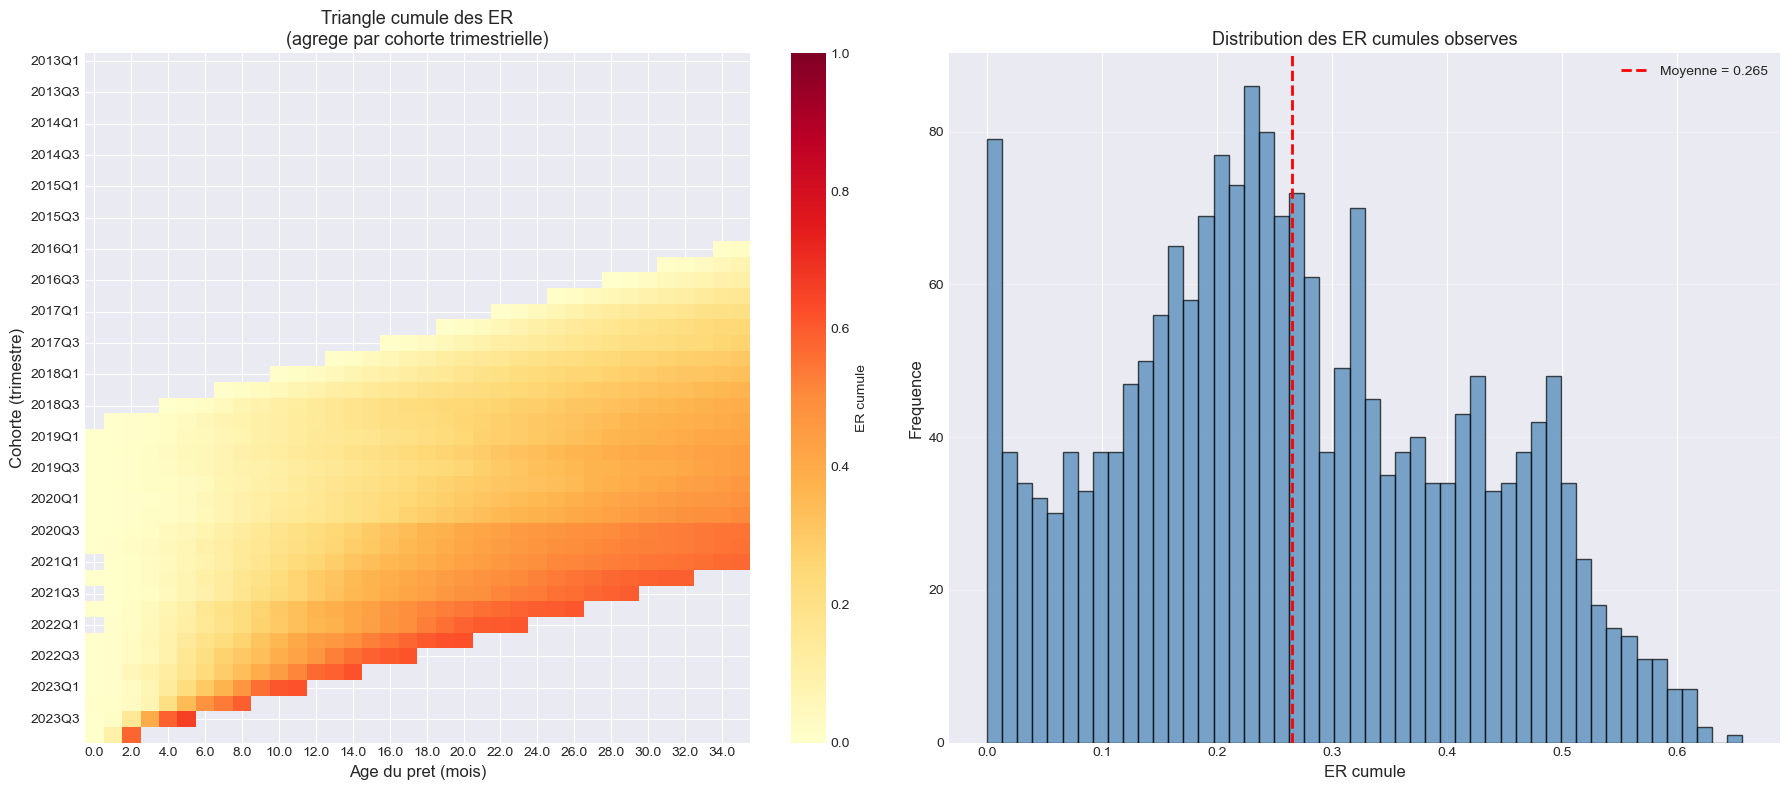

ER cumule moyen observe : 0.2649
ER cumule median : 0.2485
ER cumule max : 0.6570


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Triangle complet
sns.heatmap(triangle_cumule.iloc[:, :36], annot=False, cmap='YlOrRd',
            cbar_kws={'label': 'ER cumule'}, ax=axes[0], vmin=0, vmax=1)
axes[0].set_xlabel('Age du pret (mois)', fontsize=12)
axes[0].set_ylabel('Cohorte (trimestre)', fontsize=12)
axes[0].set_title('Triangle cumule des ER\n(agrege par cohorte trimestrielle)', fontsize=13)

# Distribution des ER cumules observes
er_values = triangle_cumule.values.flatten()
er_values = er_values[~np.isnan(er_values)]
axes[1].hist(er_values, bins=50, edgecolor='black', color='steelblue', alpha=0.7)
axes[1].set_xlabel('ER cumule', fontsize=12)
axes[1].set_ylabel('Frequence', fontsize=12)
axes[1].set_title('Distribution des ER cumules observes', fontsize=13)
axes[1].axvline(np.nanmean(er_values), color='red', linestyle='--', 
                linewidth=2, label=f'Moyenne = {np.nanmean(er_values):.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"ER cumule moyen observe : {np.nanmean(er_values):.4f}")
print(f"ER cumule median : {np.nanmedian(er_values):.4f}")
print(f"ER cumule max : {np.nanmax(er_values):.4f}")

In [13]:
import numpy as np
import pandas as pd

print("=== CHECK COHORTES / AGES ===")
print("cohorte min/max :", df_recent["Cohorte"].min(), "->", df_recent["Cohorte"].max())
print("nb cohortes     :", df_recent["Cohorte"].nunique())
print("age min/max     :", df_recent["AGE_PRET"].min(), "->", df_recent["AGE_PRET"].max())

print("\n=== CHECK EAD INITIAL ===")
ead_stats = ead_initial.describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99])
print(ead_stats)
print("5 plus petites cohortes (EAD):")
print(ead_initial.sort_values().head(5))

print("\n=== CHECK RA vs EAD (par cohorte) ===")
ra_tot = df_recent.groupby("Cohorte")["RA"].sum()
ratio_ra_ead = (ra_tot / ead_initial).sort_values(ascending=False)
print("Top 10 RA_total / EAD_initial :")
print(ratio_ra_ead.head(10))
print("Bottom 10 RA_total / EAD_initial :")
print(ratio_ra_ead.tail(10))

print("\n=== CHECK TRIANGLE VOLUME (nb obs par cellule) ===")
vol_flat = triangle_volume.values.flatten()
vol_flat = vol_flat[~np.isnan(vol_flat)]
print(pd.Series(vol_flat).describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99]))

print("\nTop 15 cellules les plus fragiles (plus petit volume, >0):")
tmp = triangle_volume.stack().reset_index()
tmp.columns = ["Cohorte","AGE_PRET","n"]
tmp_pos = tmp[tmp["n"] > 0].sort_values("n").head(15)
print(tmp_pos.to_string(index=False))

print("\n=== CHECK 'ROUGE TROP TOT' SUR 2022-2023 (ages 0-6) ===")
# adapte si tes ages commencent à 1
sus = triangle_cumule.loc[triangle_cumule.index >= "2022Q1", triangle_cumule.columns <= 6]
print("ER cumule max (2022+ ; age<=6) :", np.nanmax(sus.values))
print("Top 10 cellules ER cumule (2022+ ; age<=6) :")
sus_stack = sus.stack().reset_index()
sus_stack.columns = ["Cohorte","AGE_PRET","ER_cum"]
print(sus_stack.sort_values("ER_cum", ascending=False).head(10).to_string(index=False))

print("\n=== CHECK MONOTONIE (ER cumule ne doit pas baisser) ===")
# calc baisse max par cohorte
diffs = triangle_cumule.diff(axis=1)
min_drop = diffs.min(axis=1)  # plus négatif = baisse
print("pire baisse (toutes cohortes) :", np.nanmin(min_drop.values))
print("cohortes avec baisse < -1e-6 :")
print(min_drop[min_drop < -1e-6].sort_values().head(10))

print("\n=== SUGGESTION MASQUE VOLUME ===")
for thr in [2,5,10,20,50]:
    filled = (~triangle_cumule.mask(triangle_volume < thr).isna()).sum().sum()
    total = triangle_cumule.size
    print(f"seuil n<{thr:>2} -> remplissage {filled/total:.1%}")

=== CHECK COHORTES / AGES ===
cohorte min/max : 2013Q1 -> 2023Q4
nb cohortes     : 44
age min/max     : 0.0 -> 131.0

=== CHECK EAD INITIAL ===
count    4.400000e+01
mean     2.735623e+07
std      1.896054e+07
min      1.914997e+05
1%       6.127218e+05
5%       3.685576e+06
10%      5.617989e+06
25%      9.897225e+06
50%      2.344474e+07
75%      4.260178e+07
90%      5.580136e+07
95%      5.939859e+07
99%      6.029236e+07
max      6.071318e+07
Name: EAD_initial, dtype: float64
5 plus petites cohortes (EAD):
Cohorte
2023Q4     191499.70
2023Q3    1171085.97
2023Q2    3502338.28
2013Q1    4723925.39
2023Q1    5462698.00
Name: EAD_initial, dtype: float64

=== CHECK RA vs EAD (par cohorte) ===
Top 10 RA_total / EAD_initial :
Cohorte
2023Q3    0.657000
2022Q2    0.622157
2022Q4    0.620085
2023Q1    0.617204
2022Q3    0.615712
2021Q4    0.609175
2022Q1    0.609133
2021Q3    0.595108
2021Q2    0.591735
2023Q2    0.590834
dtype: float64
Bottom 10 RA_total / EAD_initial :
Cohorte
2015Q4   

# Etape BIS : 30 contrats par cohorte min 

In [14]:
# nb de contrats par cohorte
n_coh = df_recent.groupby("Cohorte").size()

# cohortes gardées
keep_coh = n_coh[n_coh >= 20].index
print("cohortes gardées :", len(keep_coh), "/", n_coh.size)

# on refait tout sur ces cohortes
df_stable = df_recent[df_recent["Cohorte"].isin(keep_coh)].copy()

# EAD initial
ead_initial_s = df_stable.groupby("Cohorte")["Capital_initial"].sum().rename("EAD_initial")

# RA marginal + cum + ER cum
ra_marg_s = (
    df_stable.groupby(["Cohorte", "AGE_PRET"], as_index=False)["RA"].sum()
    .merge(ead_initial_s.reset_index(), on="Cohorte", how="left")
    .sort_values(["Cohorte", "AGE_PRET"])
)
ra_marg_s["RA_cum"] = ra_marg_s.groupby("Cohorte")["RA"].cumsum()
ra_marg_s["ER_cumule"] = (ra_marg_s["RA_cum"] / ra_marg_s["EAD_initial"]).clip(lower=0)

triangle_cumule_s = ra_marg_s.pivot(index="Cohorte", columns="AGE_PRET", values="ER_cumule").sort_index()

# volume cellule (nb contrats observés dans la cellule)
triangle_volume_s = df_stable.pivot_table(
    index="Cohorte", columns="AGE_PRET", values="ER_obs", aggfunc="count"
)

cohortes gardées : 43 / 44


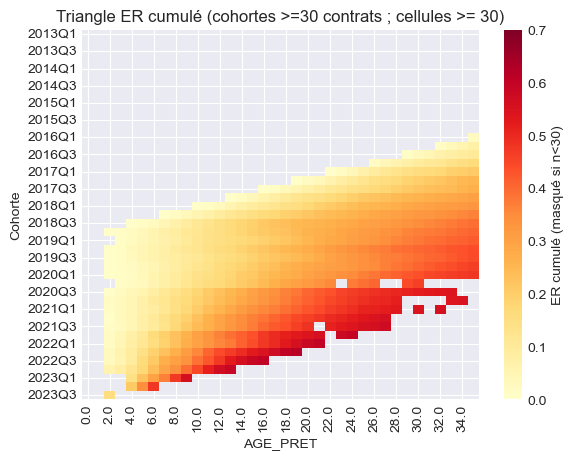

In [15]:
thr_cell = 30
tri_plot = triangle_cumule_s.mask(triangle_volume_s < thr_cell)

sns.heatmap(tri_plot.iloc[:, :36], cmap="YlOrRd", vmin=0, vmax=0.7,
            cbar_kws={"label": f"ER cumulé (masqué si n<{thr_cell})"})
plt.title(f"Triangle ER cumulé (cohortes >=30 contrats ; cellules >= {thr_cell})")
plt.show()

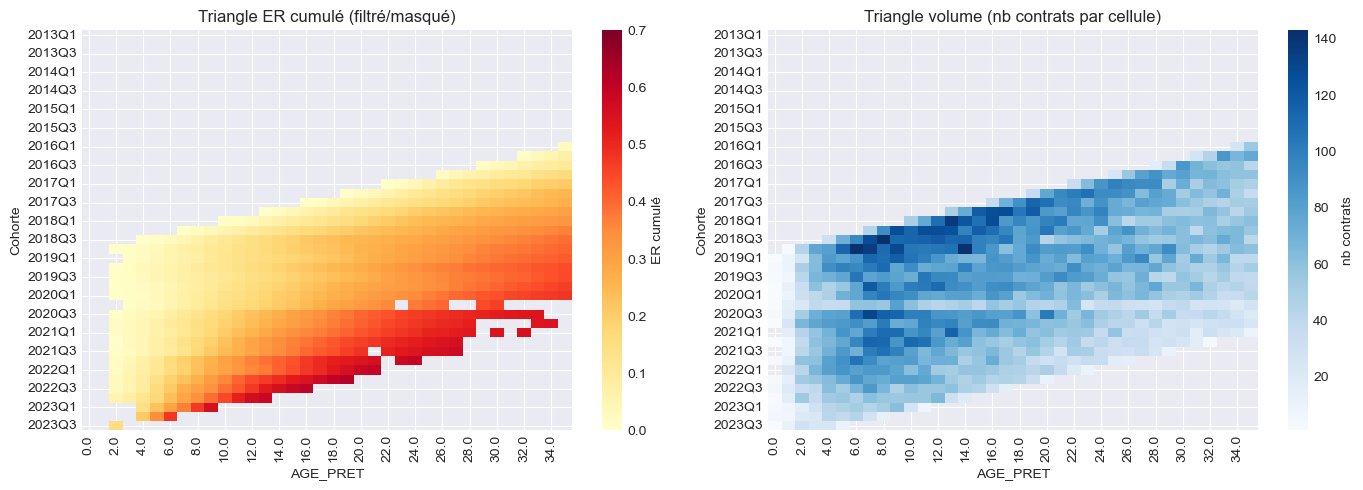

In [16]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.heatmap(tri_plot.iloc[:, :36], cmap="YlOrRd", vmin=0, vmax=0.7,
            cbar_kws={"label": "ER cumulé"}, ax=ax[0])
ax[0].set_title("Triangle ER cumulé (filtré/masqué)")

sns.heatmap(triangle_volume_s.mask(triangle_volume_s < 1).iloc[:, :36], cmap="Blues",
            cbar_kws={"label":"nb contrats"}, ax=ax[1])
ax[1].set_title("Triangle volume (nb contrats par cellule)")

plt.tight_layout()
plt.show()

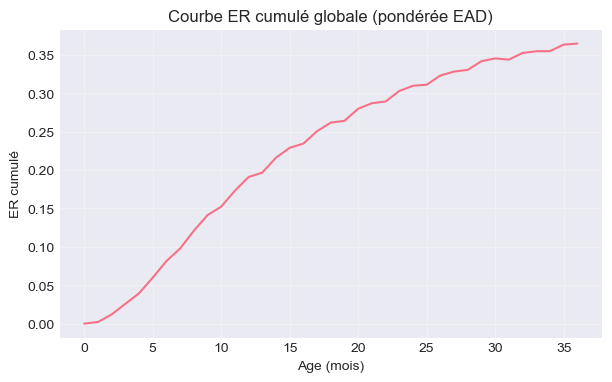

In [17]:
curve = ra_marg_s.groupby("AGE_PRET").agg(
    RA_cum_tot=("RA_cum", "sum"),
    EAD_tot=("EAD_initial", "sum")
).sort_index()
curve["ER_cum_pond"] = curve["RA_cum_tot"] / curve["EAD_tot"]

curve.loc[curve.index <= 36, "ER_cum_pond"].plot(figsize=(7,4))
plt.title("Courbe ER cumulé globale (pondérée EAD)")
plt.xlabel("Age (mois)")
plt.ylabel("ER cumulé")
plt.grid(True, alpha=0.3)
plt.show()

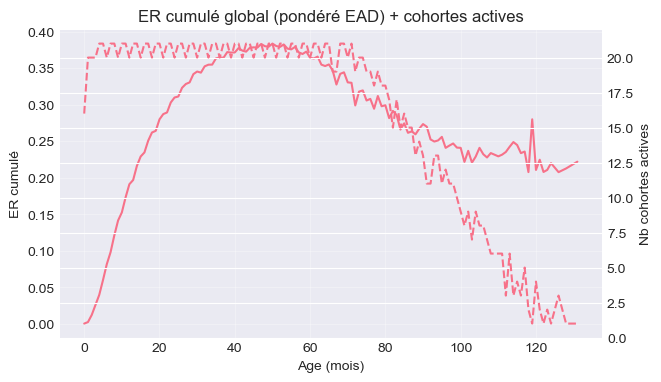

In [18]:
active = ra_marg_s.groupby("AGE_PRET")["Cohorte"].nunique().sort_index()

fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(curve.index, curve["ER_cum_pond"])
ax1.set_title("ER cumulé global (pondéré EAD) + cohortes actives")
ax1.set_xlabel("Age (mois)")
ax1.set_ylabel("ER cumulé")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(active.index, active.values, linestyle="--")
ax2.set_ylabel("Nb cohortes actives")
plt.show()

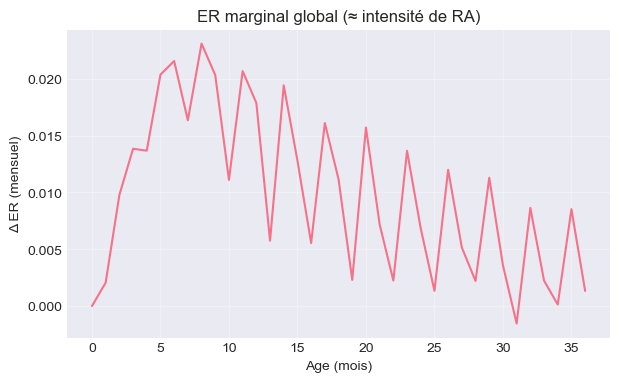

In [19]:
er_marg = curve["ER_cum_pond"].diff().fillna(0)

er_marg.loc[er_marg.index <= 36].plot(figsize=(7,4))
plt.title("ER marginal global (≈ intensité de RA)")
plt.xlabel("Age (mois)")
plt.ylabel("Δ ER (mensuel)")
plt.grid(True, alpha=0.3)
plt.show()

## Etape 5 : Calcul des facteurs de developpement

### Formule

???

### 0) Agrégation propre (ratio de sommes)

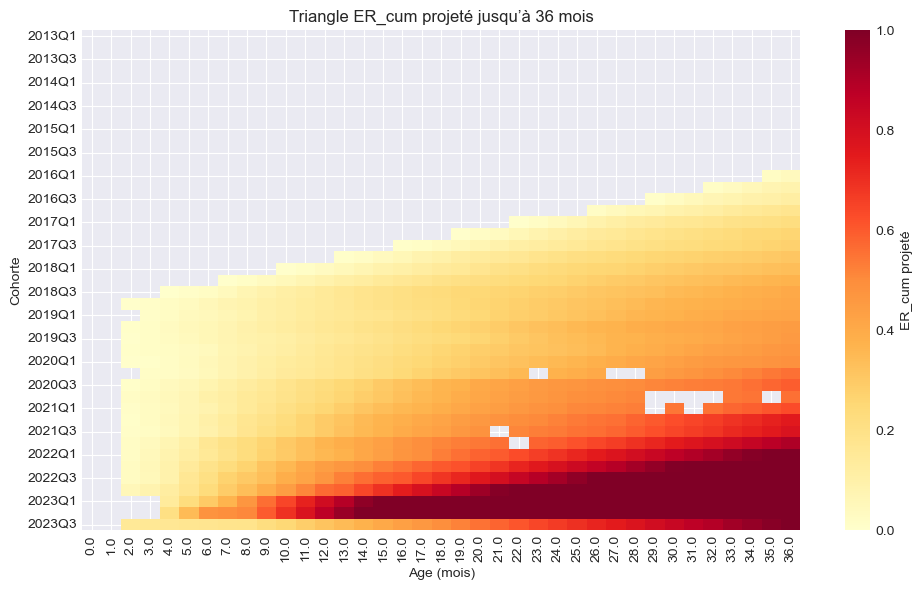

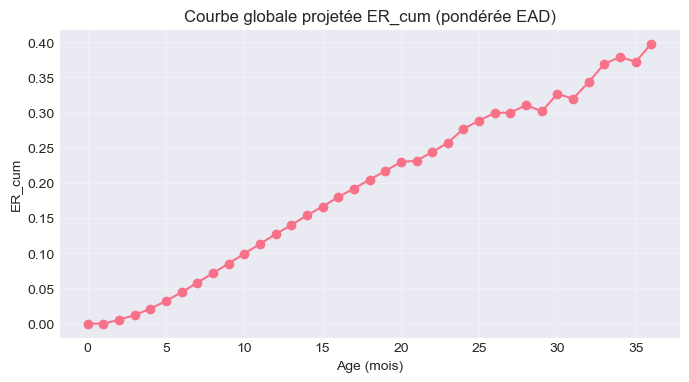

ER_global_hat (0-12):
AGE_PRET
0.0     0.000000
1.0     0.000000
2.0     0.005372
3.0     0.012045
4.0     0.021135
5.0     0.032172
6.0     0.044491
7.0     0.058120
8.0     0.071730
9.0     0.085405
10.0    0.099432
11.0    0.113224
12.0    0.127207
dtype: float64

ER_global_hat (30-36):
AGE_PRET
30.0    0.326661
31.0    0.319618
32.0    0.343468
33.0    0.369341
34.0    0.378974
35.0    0.372192
36.0    0.398076
dtype: float64

Remplissage observé : 667/1591 = 41.9%
Remplissage après projection : 876/1591 = 55.1%
Cases projetées (ajoutées) : 209/1591 = 13.1%

=== BACKTEST (on cache puis on prédit) ===
Nb points scorés: 97
MAE : 0.025808
RMSE: 0.034709
R²  : 0.922496


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

MAX_AGE = 36
MIN_N_COHORTE = 30
MIN_N_CELL = 30
MIN_COH_FOR_FACTOR = 5
HOLDOUT_AGES = 6

# 1) Filtre cohortes stables (>=30 contrats)
n_coh = df_recent.groupby("Cohorte").size()
keep = n_coh[n_coh >= MIN_N_COHORTE].index
df = df_recent[df_recent["Cohorte"].isin(keep)].copy()

# 2) EAD initial par cohorte
ead = df.groupby("Cohorte")["Capital_initial"].sum().rename("EAD_initial")

# 3) RA agrégé par (cohorte, age) puis cumul -> ER_cum
agg = (df.groupby(["Cohorte","AGE_PRET"], as_index=False)
         .agg(RA_sum=("RA","sum"),
              n=("RA","count"))
         .merge(ead.reset_index(), on="Cohorte", how="left")
         .sort_values(["Cohorte","AGE_PRET"])
      )

agg["RA_cum"] = agg.groupby("Cohorte")["RA_sum"].cumsum()
agg["ER_cum"] = (agg["RA_cum"] / agg["EAD_initial"]).clip(lower=0)

# 4) Triangles + masque cellules instables + limiter 0..36
tri = agg.pivot(index="Cohorte", columns="AGE_PRET", values="ER_cum").sort_index()
vol = agg.pivot(index="Cohorte", columns="AGE_PRET", values="n").sort_index()

cols = [c for c in tri.columns if c <= MAX_AGE]
tri = tri[cols]
vol = vol[cols]

tri_obs = tri.mask(vol < MIN_N_CELL)

# 5) Facteurs Chain Ladder sur ER_cum (pondération via sommes)
# >>> AMELIORATION: bornes plus strictes sur les facteurs
def cl_factors(tri_ratio, min_cohortes=5, min_factor=0.95, max_factor=1.20):
    cols = list(tri_ratio.columns)
    f = {}
    for j, j1 in zip(cols[:-1], cols[1:]):
        m = tri_ratio[j].notna() & tri_ratio[j1].notna() & (tri_ratio[j] > 0)
        if m.sum() < min_cohortes:
            f[j] = np.nan
            continue
        fj = tri_ratio.loc[m, j1].sum() / tri_ratio.loc[m, j].sum()
        f[j] = fj if (min_factor <= fj <= max_factor) else np.nan

    f = pd.Series(f).sort_index()
    tail_mean = f.dropna().tail(3).mean()
    return f.fillna(tail_mean)

f = cl_factors(tri_obs, min_cohortes=MIN_COH_FOR_FACTOR)

# 6) Compléter le triangle jusqu’à 36
def complete_triangle(tri_ratio, factors, max_age=36):
    hat = tri_ratio.copy()
    for coh in hat.index:
        obs = hat.loc[coh].dropna()
        if obs.empty:
            continue
        j0 = int(obs.index.max())
        val = obs.iloc[-1]
        for j in range(j0, max_age):
            if j in factors.index and pd.notna(factors.loc[j]):
                val *= factors.loc[j]
                if (j+1) in hat.columns:
                    hat.loc[coh, j+1] = val
    return hat

tri_hat = complete_triangle(tri_obs, f, max_age=MAX_AGE).clip(0, 1)

# 7) Courbe globale projetée (pondérée EAD)
ER_global_hat = (tri_hat.mul(ead.loc[tri_hat.index], axis=0).sum(axis=0) / ead.sum()).loc[:MAX_AGE]

# 8) Heatmap triangle projeté + courbe globale
plt.figure(figsize=(10,6))
sns.heatmap(tri_hat, cmap="YlOrRd", vmin=0, vmax=np.nanpercentile(tri_hat.values, 99),
            cbar_kws={"label":"ER_cum projeté"})
plt.title("Triangle ER_cum projeté jusqu’à 36 mois")
plt.xlabel("Age (mois)")
plt.ylabel("Cohorte")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(ER_global_hat.index, ER_global_hat.values, marker="o")
plt.title("Courbe globale projetée ER_cum (pondérée EAD)")
plt.xlabel("Age (mois)")
plt.ylabel("ER_cum")
plt.grid(True, alpha=0.3)
plt.show()

print("ER_global_hat (0-12):")
print(ER_global_hat.loc[:12])
print("\nER_global_hat (30-36):")
print(ER_global_hat.loc[30:36])

# 9) Taux de remplissage (observé vs projeté)
total = tri_hat.size
obs_filled = tri_obs.notna().sum().sum()
proj_filled = tri_hat.notna().sum().sum()

print(f"\nRemplissage observé : {obs_filled}/{total} = {obs_filled/total:.1%}")
print(f"Remplissage après projection : {proj_filled}/{total} = {proj_filled/total:.1%}")
print(f"Cases projetées (ajoutées) : {proj_filled-obs_filled}/{total} = {(proj_filled-obs_filled)/total:.1%}")

# 10) BACKTEST (on cache puis on prédit)
cut = tri_obs.columns[-HOLDOUT_AGES:]

tri_train = tri_obs.copy()
to_hide = tri_train[cut].notna()
tri_train.loc[:, cut] = tri_train[cut].where(~to_hide, np.nan)

f_bt = cl_factors(tri_train, min_cohortes=MIN_COH_FOR_FACTOR)

tri_hat_bt = complete_triangle(tri_train, f_bt, max_age=MAX_AGE).clip(0, 1)

obs_hidden = tri_obs[cut]
pred_hidden = tri_hat_bt[cut]
mask = to_hide & pred_hidden.notna()

mae = np.nanmean(np.abs(pred_hidden[mask] - obs_hidden[mask]))
rmse = np.sqrt(np.nanmean((pred_hidden[mask] - obs_hidden[mask])**2))

y_true = obs_hidden[mask].to_numpy().ravel()
y_pred = pred_hidden[mask].to_numpy().ravel()
ok = np.isfinite(y_true) & np.isfinite(y_pred)
y_true, y_pred = y_true[ok], y_pred[ok]

ss_res = float(np.sum((y_true - y_pred)**2))
ss_tot = float(np.sum((y_true - np.mean(y_true))**2))
r2 = np.nan if ss_tot == 0 else 1 - ss_res/ss_tot

print("\n=== BACKTEST (on cache puis on prédit) ===")
print("Nb points scorés:", int(mask.sum().sum()))
print("MAE :", round(float(mae), 6))
print("RMSE:", round(float(rmse), 6))
print("R²  :", round(float(r2), 6))